# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Saffira Arentsen
* Username: sarentsen
* Student number: s6239145
* Group (AS1, etc.): AS2

-----

In [ ]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

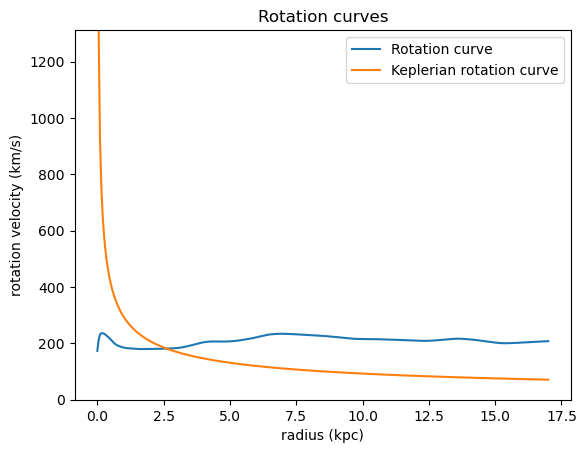

The keplerian rotation curve starts of at a really high rotaion velocity.
The keplerian rotation curve keeps keep decreasing at larger radii, whereas the rotation curves from rotcur.dat remain more or less constant at a larger radii.


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import GM_sun, kpc
r, v = np.loadtxt('rotcur.dat', comments='#', unpack=True)

plt.plot(r, v, label='Rotation curve')
plt.title('Rotation curves')
plt.xlabel('radius (kpc)')
plt.ylabel('rotation velocity (km/s)')

GM = GM_sun.value # in m^3/s^2
v_calc = np.sqrt(GM*2e10/(r[1:]*kpc.value)) / 1000 # Unit in km/s (excluding r=0)
np.savetxt('keplerian_curve.txt', (v_calc), fmt='%.18e', delimiter=' ', newline='\n',
              header='', footer='', comments='# ')
keplerian_curve = np.loadtxt('keplerian_curve.txt', comments='#')
plt.plot(r[1:], keplerian_curve, label='Keplerian rotation curve')
plt.ylim((0, np.max(keplerian_curve)))
plt.legend()
plt.show()

print('The keplerian rotation curve starts of at a really high rotaion velocity.')
print('The keplerian rotation curve keeps keep decreasing at larger radii, whereas the rotation curves\
 from rotcur.dat remain more or less constant at a larger radii.')


In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

2D slice, mean: 0.009792789185744832 and std: 0.9852478713751631
Yes this mean and standard deviation are what I expected.
This is a Gaussian distribution.


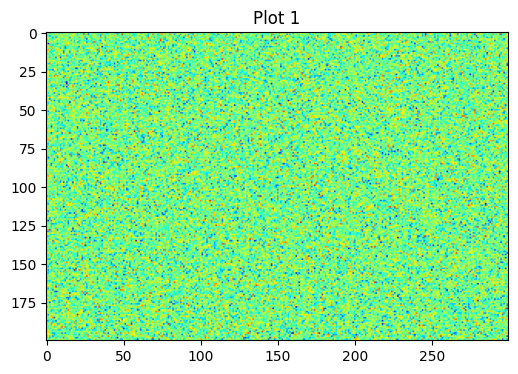

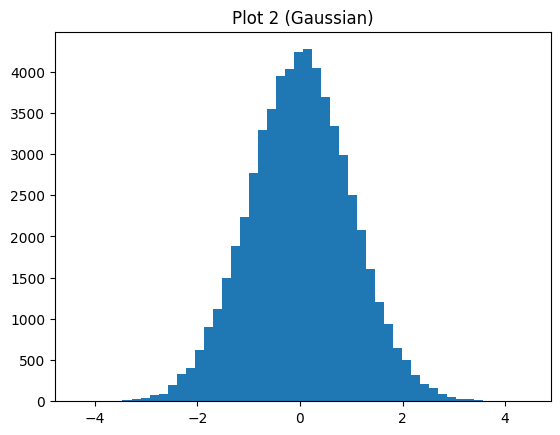

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Normal distribution
data = np.random.normal(0, 1, (200,300))
sub_data = data[:30, :30] # 2D slice with 30x30 pixels
print(f'2D slice, mean: {np.mean(sub_data)} and std: {np.std(sub_data)}')
print('Yes this mean and standard deviation are what I expected.')

plt.figure(figsize=(8, 4))
plt.title('Plot 1')
plt.imshow(data, cmap='jet')

plt.figure()
plt.hist(data.ravel(), bins=50)
plt.title('Plot 2 (Gaussian)')
print('This is a Gaussian distribution.')
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Area: 18.84955592153876
Perimeter: 15.865437575563961
Ellipse center: (1, 1), semi major: 3, semi minor: 2, angle: 0


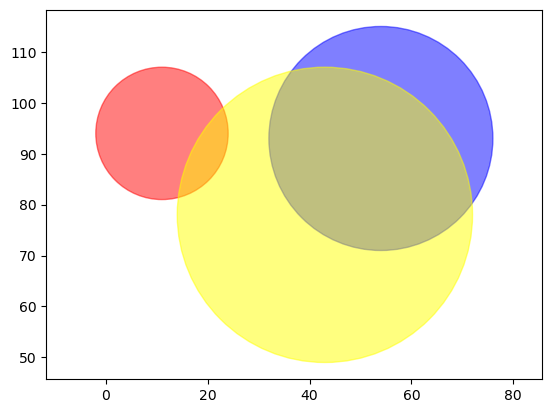

In [35]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
from math import pi, sqrt
import numpy as np

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle=0, **args):
        # We use the (sort of) astronomical angle where 'angle' defines)
        # the position angle of the major axis of a ring projected onto the sky
        # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
        # the north direction on the sky and the major axis of the receding half of the
        # galaxy (Rots 1975, astron, astrophys 45, 43).
        # Here we assume (!) north is in the positive Y direction.
        # If not, you need to correct the angle for the rotation of the image.
        # Parameter 'position_angle' enters in degrees
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        self.semi_major = semi_major
        self.semi_minor = semi_minor
        self.position_angle = position_angle
        XY = (xc, yc)                  # MPL requires center as a tuple
        self.XY = XY
        angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)
        
    def calc_area(self):
        area = pi*self.semi_major*self.semi_minor
        return area
    
    def perimeter(self):
        a = self.semi_major
        b = self.semi_minor
        perimeter = pi * ( 3*(a+b) - sqrt( (3*a + b) * (a + 3*b) ) ) # Ramanujan's formula
        return perimeter
    
    def __str__(self):
        return f'Ellipse center: {self.XY}, semi major: {self.semi_major}, semi minor: {self.semi_minor}, angle: {self.position_angle}'

class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius, **args):
        super().__init__(xc, yc, radius, radius, **args)

# ellipse examples
ellipse = AstroEllipse(1, 1, 3, 2)
print(f'Area: {ellipse.calc_area()}')
print(f'Perimeter: {ellipse.perimeter()}')
print(ellipse)

def create_circle(color):
    '''Returns a MyCircle object with a random center and a random radius, with the specified color'''
    circle = MyCircle(np.random.randint(100), np.random.randint(100), np.random.randint(50), fill=True, color=color, alpha=0.5)
    return circle

# Plot 3 random circles
fig, frame = plt.subplots()
frame.add_patch(create_circle('red'))
frame.add_patch(create_circle('blue'))
frame.add_patch(create_circle('yellow'))
plt.axis('equal') # Equal axis, so that they look like circles
    
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

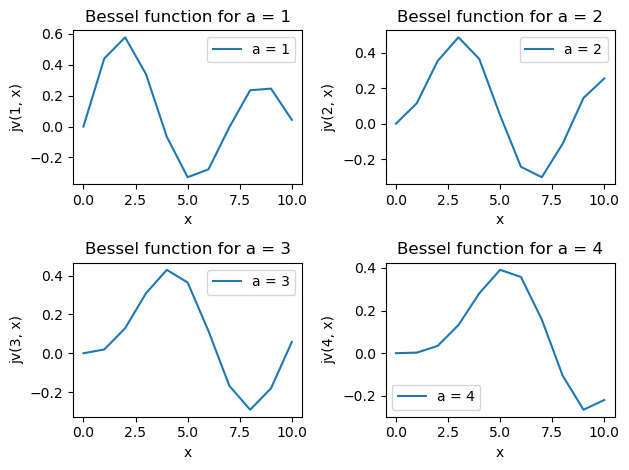

In [24]:
from scipy.special import jv
from matplotlib.pyplot import figure, show
import numpy as np

x = np.arange(0,11)

# Plotting the solutions of Bessel's differential equation for a = 1, 2, 3 and 4
fig = figure()
for i in range(1, 5):
    frame = fig.add_subplot(2, 2, i) # 2 rows, 2 columns, index i
    frame.plot(jv(i, x), label=f'a = {i}')
    frame.set_title(f'Bessel function for a = {i}')
    frame.set_xlabel('x')
    frame.set_ylabel(f'jv({i}, x)')
    frame.legend()
fig.tight_layout()
fig.savefig('bessel.png', transparent=True)
show()

The figure is attached below:

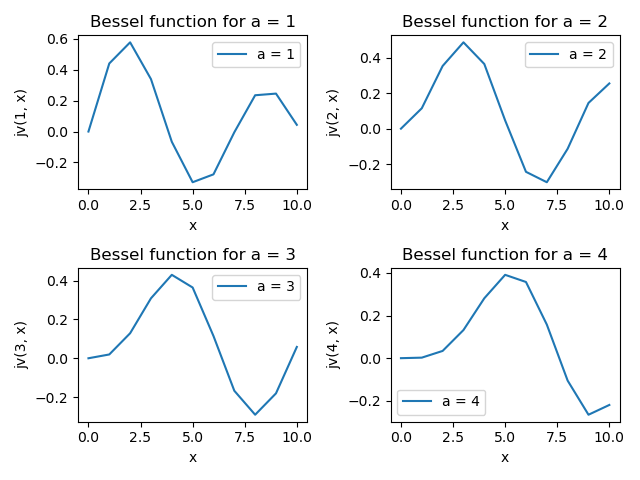

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

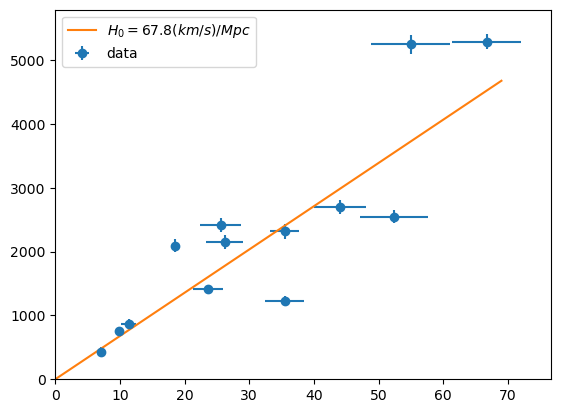

In [64]:
from matplotlib.pyplot import figure, show
import numpy as np

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
d, v, d_error, v_error = data[0::4], data[1::4], data[2::4], data[3::4]

fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.errorbar(d, v, yerr=v_error, xerr=d_error, fmt='o', label='data')
x = np.arange(0, 70)
frame.plot(x, 67.8*x, label=r'$H_0 = 67.8 (km/s)/Mpc$')
frame.set_ylim(0, max(v)+500)
frame.set_xlim(0, max(d)+10)
frame.legend()
show()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")